In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

### Importando los datos

In [2]:
path_file = r"..\mediciones\clase1\clean\mediciones1_clean.csv"

In [3]:
datos = pd.read_csv(path_file, sep=",")
datos.head(5)

,vpp,vpp_error,10 Hz,100 Hz,1 KHz,10 KHz,100 KHz,1 MHz,vt_error
0,2.04,0.06,0.43,0.63,0.60,0.43,0.02,0.010,0.01
1,4.00,0.10,1.25,1.34,1.28,1.54,0.24,0.003,0.01
2,6.00,0.20,2.04,2.11,2.01,2.73,1.06,0.003,0.01
3,8.00,0.20,2.82,2.79,2.68,3.91,1.61,0.002,0.01
4,10.00,0.30,3.58,3.54,3.43,5.03,1.87,0.002,0.01


### Funciones

In [4]:
def funcion_lineal(x, m, b):
    return m * x + b

In [5]:
def ajuste_lineal_ponderados(x, y, y_error, funcion):
    """
    Ajuste lineal ponderado a los datos (x, y) con errores y_error.
    
    Parámetros:
    x : array_like
        Valores de la variable independiente.
    y : array_like
        Valores de la variable dependiente.
    y_error : array_like
        Errores asociados a los valores de y.
    funcion : callable
        Función modelo a ajustar.

    Retorna:
    popt : array
        Parámetros óptimos del ajuste (pendiente, intercepto).
    pcov : 2D array
        Matriz de covarianza de los parámetros ajustados.
    """

    # Realizar el ajuste ponderado
    popt, pcov = curve_fit(
        funcion, 
        x,
        y,
        sigma=y_error,
        absolute_sigma=True
    )
    
    return popt, pcov

In [6]:
def metricas_ajuste(x, y, y_err, popt, funcion_modelo):
    """
    Calcula R^2, Chi^2 y Chi^2 reducido para un ajuste.
    
    Parámetros:
    - x, y: Datos de entrada (array-like).
    - y_err: Incertidumbres en Y (array-like).
    - popt: Lista de parámetros optimizados devueltos por curve_fit.
    - funcion_modelo: La función usada en curve_fit (ej. recta).
    """
    x = np.array(x)
    y = np.array(y)
    y_err = np.array(y_err)
    
    # Valore predichos por el modelo
    y_pred = funcion_modelo(x, *popt)
    
    # 1. Residuales
    residuos = y - y_pred
    
    # 2. Coeficiente de Determinación R^2
    ss_res = np.sum(residuos**2)                  # Suma de cuadrados residual
    ss_tot = np.sum((y - np.mean(y))**2)         # Suma de cuadrados total
    r2 = 1 - (ss_res / ss_tot)
    
    # 3. Chi-cuadrado (Chi2)
    chi2 = np.sum((residuos / y_err)**2)
    
    # 4. Grados de libertad (nu = n - p)
    # n: número de datos, p: número de parámetros ajustados
    n = len(y)
    p = len(popt)
    dof = n - p
    
    # 5. Chi-cuadrado reducido (Chi2_nu)
    chi2_red = chi2 / dof if dof > 0 else np.nan
    
    return {
        "R2": r2,
        "Chi2": chi2,
        "Grados_Libertad": dof,
        "Chi2_reducido": chi2_red
    }

### Gráficamos las mediciones observadas

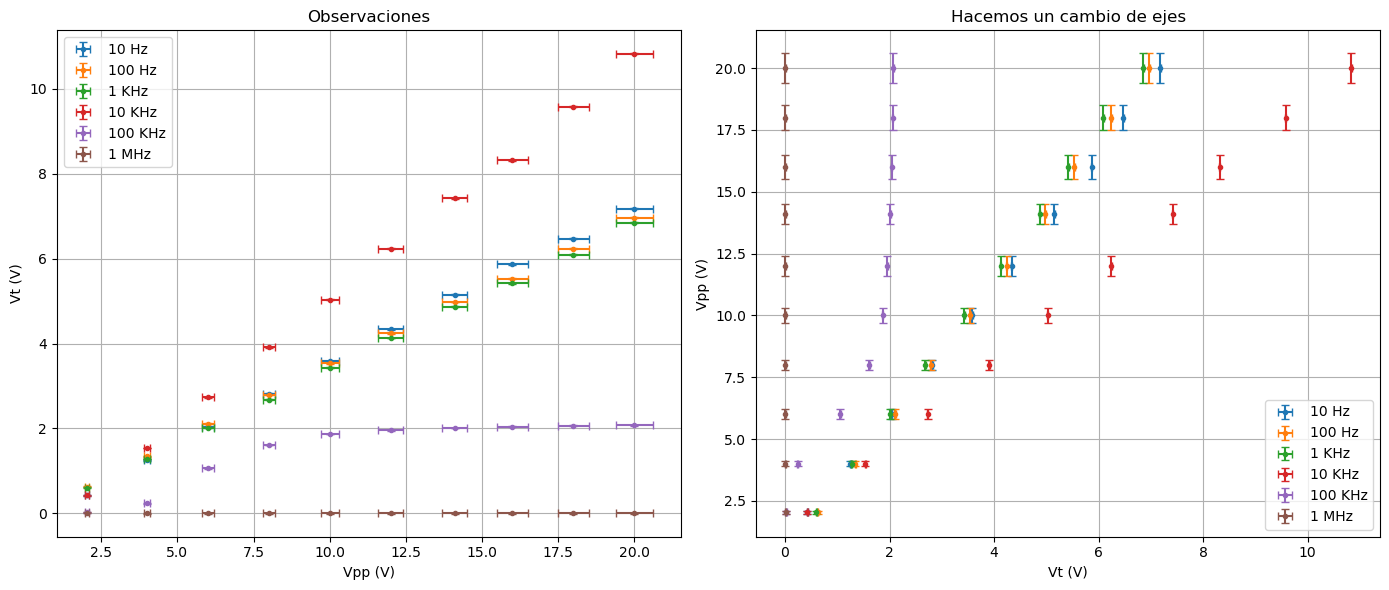

In [7]:
# 1 fila, 2 columnas (puedes ajustar el tamaño general con figsize)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICO 1 (Izquierda: axes[0]) ---
# Este es el gráfico que ya tenías escrito
for label, vt in datos.iloc[:, 2:8].items():
    axes[0].errorbar(
        x=datos["vpp"],
        y=vt,
        yerr=datos["vt_error"],
        xerr=datos["vpp_error"],
        fmt='.',
        capsize=3,
        label=label
    )

axes[0].set_title("Observaciones")
axes[0].set_xlabel("Vpp (V)")
axes[0].set_ylabel("Vt (V)")
axes[0].legend()
axes[0].grid(True)

# --- GRÁFICO 2 (Derecha: axes[1]) ---
# Este es el gráfico que ya tenías escrito
for label, vt in datos.iloc[:, 2:8].items():
    axes[1].errorbar(
        x=vt,
        y=datos["vpp"],
        yerr=datos["vpp_error"],
        xerr=datos["vt_error"],
        fmt='.',
        capsize=3,
        label=label
    )

axes[1].set_title("Hacemos un cambio de ejes")
axes[1].set_xlabel("Vt (V)")
axes[1].set_ylabel("Vpp (V)")
axes[1].legend()
axes[1].grid(True)

# Ajuste final
plt.tight_layout()
plt.show()

### Ajuste Lineal

### El modelo: Vpp = m.Vt + b

realizamos un cambio de ejes. Y = Vpp, X = Vt

In [8]:
resultados = pd.DataFrame(columns=["frecuencia", "m", "b", "m_error", "b_error", "Cov","R2", "Chi2", "Chi2_reducido"])

In [9]:
for freq, datos_col in datos.iloc[:, 2:8].items():
    popt, pcov = ajuste_lineal_ponderados(datos[freq], datos["vpp"], datos["vpp_error"], funcion_lineal)
    m, b = popt
    cov = pcov[0][1]  # Covarianza entre m y b
    m_error, b_error = np.sqrt(pcov[0][0]), np.sqrt(pcov[1][1])

    metrics = metricas_ajuste(datos[freq], datos["vpp"], datos["vpp_error"], popt, funcion_lineal)

    resultados.loc[len(resultados)] = {
        "frecuencia": freq,
        "m": m,
        "b": b,
        "m_error": m_error,
        "b_error": b_error,
        "Cov": cov,
        "R2": metrics["R2"],
        "Chi2": metrics["Chi2"],
        "Chi2_reducido": metrics["Chi2_reducido"],
    }

In [10]:
resultados

,frecuencia,m,b,m_error,b_error,Cov,R2,Chi2,Chi2_reducido
0,10 Hz,2.568808,0.886788,0.036107,0.062501,-0.001507,0.997740,4.752411,0.594051
1,100 Hz,2.792154,0.262692,0.039236,0.068661,-0.001982,0.999011,2.049391,0.256174
2,1 KHz,2.858651,0.322786,0.040166,0.068039,-0.001994,0.999473,1.021784,0.127723
3,10 KHz,1.732382,1.298872,0.024341,0.058782,-0.000875,0.999638,0.744916,0.093114
4,100 KHz,5.060685,2.060456,0.075772,0.053731,-0.002038,0.659126,605.611900,75.701487
5,1 MHz,-672.025855,8.603981,12.848652,0.101989,-1.166192,-0.236080,2330.673329,291.334166


In [11]:
path_ajuste = r".\clase1\ajuste_lineal_resultados.csv"
resultados.to_csv(path_ajuste, index=False)